# Marketing A/B Test Analysis


**Business question:** Does showing a user the *ad* (test group) vs. a *PSA / public service announcement* (control group) increase conversion rate?

**The setup:** A company ran a marketing campaign where most users were shown a regular ad, while a small holdout group was shown a PSA (public service announcement) instead — essentially a "fake ad" used as the control group, so researchers could isolate the effect of the ad content itself, not just "seeing something on screen."

**Project** Does the ad actually cause people to convert, or would they have converted anyway regardless of what they saw? Using a PSA as the control (instead of showing nothing) is a classic experimental design trick, it accounts for general exposure/attention effects, isolating the ad's real incremental impact

## 1. Setup

In [1]:
import sys
!{sys.executable} -m pip install seaborn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(42)


## 2. Load & clean data

Expected columns (Kaggle version): `Unnamed: 0`, `user id`, `test group` (ad/psa), `converted` (True/False),
`total ads`, `most ads day`, `most ads hour`. Column names can vary slightly — adjust below if needed.

In [3]:
df = pd.read_csv("marketing_AB.csv")

# Drop unnamed index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Standardize column names: lowercase, underscores
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print(df.columns.tolist())
df.head()


['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [4]:
# Basic info
print(df.shape)
df.info()
df.isnull().sum()


(588101, 6)
<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user_id        588101 non-null  int64
 1   test_group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total_ads      588101 non-null  int64
 4   most_ads_day   588101 non-null  str  
 5   most_ads_hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [5]:
# Ensure 'converted' is boolean/int, and check group balance
df["converted"] = df["converted"].astype(bool)
print(df["test_group"].value_counts())
print(df["test_group"].value_counts(normalize=True))


test_group
ad     564577
psa     23524
Name: count, dtype: int64
test_group
ad     0.96
psa    0.04
Name: proportion, dtype: float64


**Note:** This dataset is naturally imbalanced (~96% ad group, ~4% PSA group) — not a 50/50 split like a
typical designed experiment. Call this out in your write-up: it affects statistical power and is a realistic
nuance (many real-world tests aren't perfectly balanced, e.g. holding out a small control group).

## 3. Experiment framing

- **H0 (null):** Conversion rate is the same for the ad group and the PSA group.
- **H1 (alternative):** Conversion rate differs between the ad group and the PSA group (two-sided), or is higher
  for the ad group (one-sided, since PSA is expected to be a weaker "placebo" ad).
- **Primary metric:** conversion rate
- **Guardrail / secondary metric:** total ads seen (exposure)
- **Significance level:** α = 0.05


## 4. Exploratory analysis

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


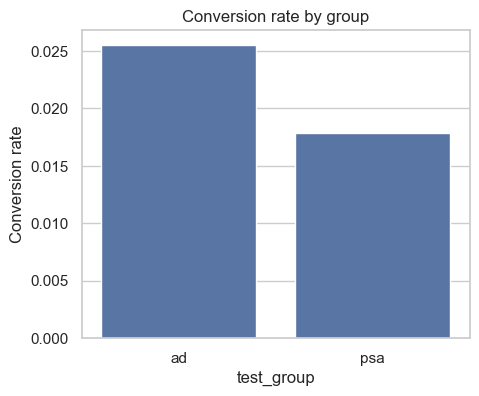

In [6]:
conv_rates = df.groupby("test_group")["converted"].mean()
print(conv_rates)

plt.figure(figsize=(5,4))
sns.barplot(x=conv_rates.index, y=conv_rates.values)
plt.ylabel("Conversion rate")
plt.title("Conversion rate by group")
plt.show()


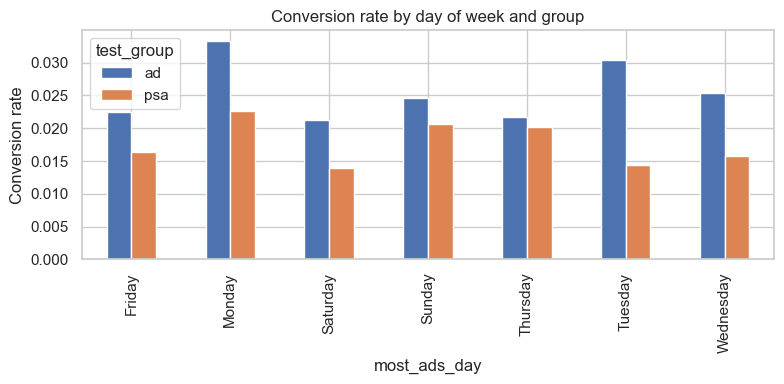

In [7]:
# Conversion by day of week
if "most_ads_day" in df.columns:
    day_conv = df.groupby(["most_ads_day", "test_group"])["converted"].mean().unstack()
    day_conv.plot(kind="bar", figsize=(8,4))
    plt.ylabel("Conversion rate")
    plt.title("Conversion rate by day of week and group")
    plt.tight_layout()
    plt.show()


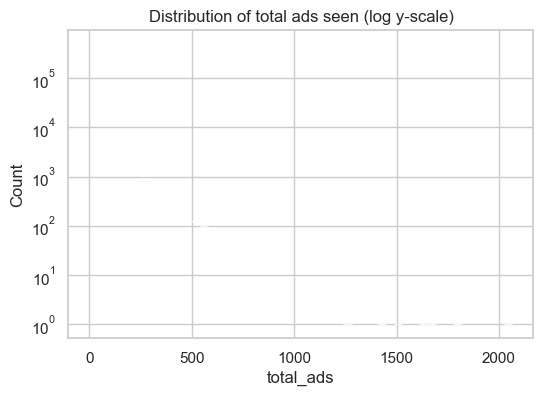

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64
99.9th percentile: 499.9000000000233


In [8]:
# Distribution of total ads seen (exposure) - check for outliers
plt.figure(figsize=(6,4))
sns.histplot(df["total_ads"], bins=50, log_scale=(False, True))
plt.title("Distribution of total ads seen (log y-scale)")
plt.show()

print(df["total_ads"].describe())
print("99.9th percentile:", df["total_ads"].quantile(0.999))


In [9]:
# Flag extreme outliers (e.g., users who saw an unrealistic number of ads)
outlier_cutoff = df["total_ads"].quantile(0.999)
print(f"Users above {outlier_cutoff:.0f} ads: {(df['total_ads'] > outlier_cutoff).sum()}")

# Keep a version without extreme outliers for sensitivity checks later
df_no_outliers = df[df["total_ads"] <= outlier_cutoff].copy()


Users above 500 ads: 589


## 5. Statistical testing

In [10]:
# Two-proportion z-test
group_ad = df[df["test_group"] == "ad"]["converted"]
group_psa = df[df["test_group"] == "psa"]["converted"]

count = np.array([group_ad.sum(), group_psa.sum()])
nobs = np.array([len(group_ad), len(group_psa)])

z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.6f}")

rate_ad = count[0] / nobs[0]
rate_psa = count[1] / nobs[1]
lift = (rate_ad - rate_psa) / rate_psa * 100
print(f"Conversion rate (ad):  {rate_ad:.4%}")
print(f"Conversion rate (psa): {rate_psa:.4%}")
print(f"Relative lift: {lift:.2f}%")


z-statistic: 7.3701
p-value: 0.000000
Conversion rate (ad):  2.5547%
Conversion rate (psa): 1.7854%
Relative lift: 43.09%


In [11]:
# Confidence intervals for each group's conversion rate
ci_ad = proportion_confint(count[0], nobs[0], alpha=0.05, method="normal")
ci_psa = proportion_confint(count[1], nobs[1], alpha=0.05, method="normal")
print(f"Ad group 95% CI:  {ci_ad}")
print(f"PSA group 95% CI: {ci_psa}")


Ad group 95% CI:  (0.0251349995427061, 0.025958119730661394)
PSA group 95% CI: (0.016161914715211324, 0.019546298173753137)


In [12]:
# Statistical power of the test as actually run
effect_size = proportion_effectsize(rate_ad, rate_psa)
analysis = NormalIndPower()
power = analysis.power(effect_size=effect_size, nobs1=nobs[0], ratio=nobs[1]/nobs[0], alpha=0.05)
print(f"Observed effect size (Cohen's h): {effect_size:.4f}")
print(f"Statistical power achieved: {power:.4f}")

# How many PSA-group samples would we have needed for 80% power, given this effect size?
required_n_psa = analysis.solve_power(effect_size=effect_size, power=0.8, alpha=0.05, ratio=1)
print(f"Samples needed per group (1:1 ratio) for 80% power: {required_n_psa:.0f}")


Observed effect size (Cohen's h): 0.0530
Statistical power achieved: 1.0000
Samples needed per group (1:1 ratio) for 80% power: 5588


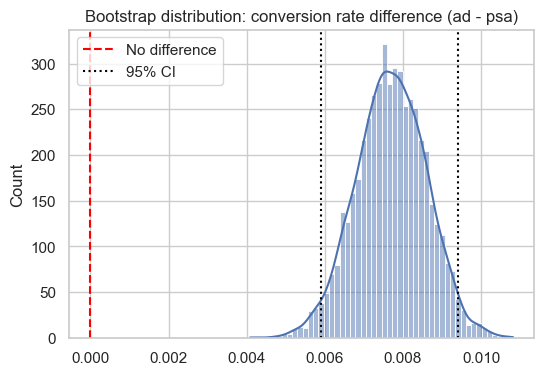

Bootstrap 95% CI for difference: [0.5911%, 0.9412%]


In [13]:
# Bootstrap the difference in conversion rate to visualize the CI directly
n_boot = 5000
boot_diffs = []
ad_vals = group_ad.values.astype(int)
psa_vals = group_psa.values.astype(int)

for _ in range(n_boot):
    boot_ad = np.random.choice(ad_vals, size=len(ad_vals), replace=True).mean()
    boot_psa = np.random.choice(psa_vals, size=len(psa_vals), replace=True).mean()
    boot_diffs.append(boot_ad - boot_psa)

boot_diffs = np.array(boot_diffs)
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

plt.figure(figsize=(6,4))
sns.histplot(boot_diffs, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--", label="No difference")
plt.axvline(ci_lower, color="black", linestyle=":", label="95% CI")
plt.axvline(ci_upper, color="black", linestyle=":")
plt.legend()
plt.title("Bootstrap distribution: conversion rate difference (ad - psa)")
plt.show()

print(f"Bootstrap 95% CI for difference: [{ci_lower:.4%}, {ci_upper:.4%}]")


## 6. Segmentation — dose-response and time effects

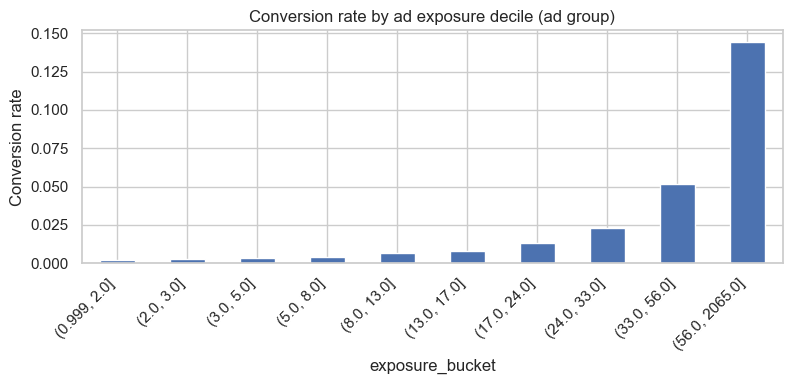

In [14]:
# Dose-response: does conversion rate increase with more ad exposure? (ad group only)
ad_group = df[df["test_group"] == "ad"].copy()
ad_group["exposure_bucket"] = pd.qcut(ad_group["total_ads"], q=10, duplicates="drop")

dose_response = ad_group.groupby("exposure_bucket", observed=True)["converted"].mean()
plt.figure(figsize=(8,4))
dose_response.plot(kind="bar")
plt.ylabel("Conversion rate")
plt.title("Conversion rate by ad exposure decile (ad group)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


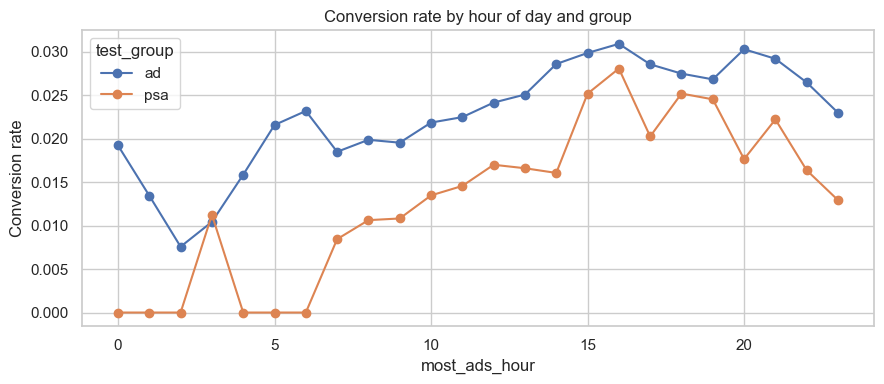

In [15]:
# Conversion rate by hour of day, split by group (if column exists)
if "most_ads_hour" in df.columns:
    hour_conv = df.groupby(["most_ads_hour", "test_group"])["converted"].mean().unstack()
    hour_conv.plot(figsize=(9,4), marker="o")
    plt.ylabel("Conversion rate")
    plt.title("Conversion rate by hour of day and group")
    plt.tight_layout()
    plt.show()


**Questions to answer in your write-up:**
- Is the ad effect roughly consistent across days/hours, or concentrated in specific windows?
- Is there a clear dose-response relationship (more exposure → higher conversion), or does it plateau?
- Are there any segments where PSA performs comparably to ads (i.e., where the ad spend isn't earning its keep)?


## 7. Multi-Armed Bandit simulation (differentiator)

This section simulates how a **Thompson Sampling** bandit would have allocated traffic between the two arms
(ad vs. psa), compared to the fixed 96/4 split actually used. The goal: show how much faster/cheaper it is
to identify the winning arm with adaptive allocation vs. a static A/B split.


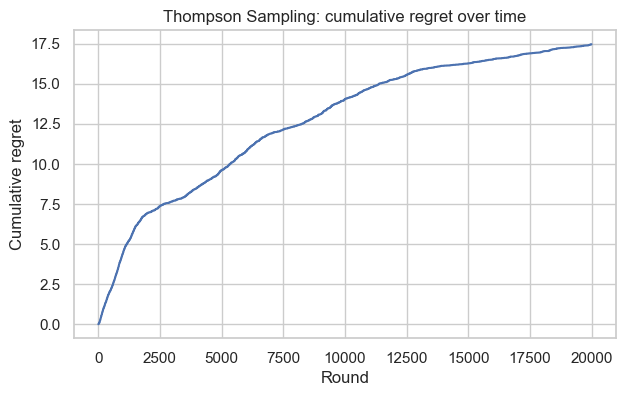

Fraction of traffic sent to losing arm (PSA) — bandit: 11.34%
Fraction of traffic sent to losing arm (PSA) — actual fixed split: 4.00%


In [16]:
def simulate_thompson_sampling(true_rates, n_rounds, seed=42):
    """
    true_rates: dict {arm_name: true conversion probability}
    Returns: history of chosen arm and cumulative regret
    """
    rng = np.random.default_rng(seed)
    arms = list(true_rates.keys())
    alpha = {a: 1 for a in arms}  # Beta prior successes
    beta = {a: 1 for a in arms}   # Beta prior failures

    best_rate = max(true_rates.values())
    cumulative_regret = []
    chosen_arms = []
    regret_so_far = 0.0

    for t in range(n_rounds):
        # Sample from each arm's posterior, pick the highest
        samples = {a: rng.beta(alpha[a], beta[a]) for a in arms}
        chosen = max(samples, key=samples.get)
        chosen_arms.append(chosen)

        # Simulate outcome
        reward = rng.random() < true_rates[chosen]
        if reward:
            alpha[chosen] += 1
        else:
            beta[chosen] += 1

        regret_so_far += (best_rate - true_rates[chosen])
        cumulative_regret.append(regret_so_far)

    return chosen_arms, cumulative_regret

# Use the observed conversion rates from the real data as the "true" rates for simulation
true_rates = {"ad": rate_ad, "psa": rate_psa}
n_rounds = 20000

chosen_arms, cumulative_regret = simulate_thompson_sampling(true_rates, n_rounds)

plt.figure(figsize=(7,4))
plt.plot(cumulative_regret)
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.title("Thompson Sampling: cumulative regret over time")
plt.show()

# What fraction of traffic went to the losing arm (psa) under the bandit vs. the real 96/4 split?
psa_fraction_bandit = chosen_arms.count("psa") / len(chosen_arms)
psa_fraction_actual = nobs[1] / nobs.sum()
print(f"Fraction of traffic sent to losing arm (PSA) — bandit: {psa_fraction_bandit:.2%}")
print(f"Fraction of traffic sent to losing arm (PSA) — actual fixed split: {psa_fraction_actual:.2%}")


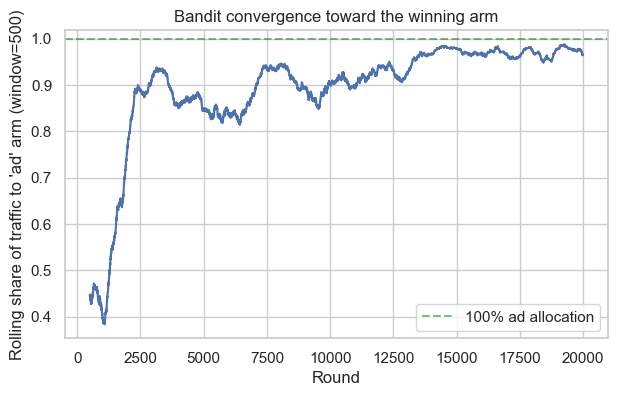

In [17]:
# Compare: how many rounds did it take the bandit to "converge" (consistently favor the winning arm)?
window = 500
rolling_ad_share = pd.Series([1 if a == "ad" else 0 for a in chosen_arms]).rolling(window).mean()

plt.figure(figsize=(7,4))
plt.plot(rolling_ad_share)
plt.axhline(1.0, color="green", linestyle="--", alpha=0.5, label="100% ad allocation")
plt.xlabel("Round")
plt.ylabel(f"Rolling share of traffic to 'ad' arm (window={window})")
plt.title("Bandit convergence toward the winning arm")
plt.legend()
plt.show()


**Takeaway to write up:** compare the total "cost" (conversions lost by serving the underperforming PSA arm)
under the fixed A/B split actually used vs. what an adaptive bandit would have cost, at the same sample size.
This is the kind of tradeoff (statistical rigor / clean inference vs. real-time optimization) that's worth
discussing explicitly — fixed A/B tests are still often preferred when you need a clean, unbiased effect-size
estimate for a business decision, while bandits are better when the goal is pure exploitation.


## 8. Business recommendation

We tested whether showing users an ad (test group) versus a public service announcement (control group) increases conversion rate, using data from 588,101 users. The ad group converted at 2.55%, versus 1.79% for the PSA group, a relative lift of 43.1%, which is statistically significant (p < 0.0001, 95% CI for the difference: [0.59%, 0.94%]). The test achieved essentially full statistical power (100%), so we have high confidence in this result. The sample size was well beyond what was needed to detect an effect of this size.
We also found a clear dose-response relationship: conversion rate increases with the number of ads a user is exposed to, though the largest gains come from initial exposure rather than continuing to scale up ad frequency indefinitely, suggesting a point of diminishing returns worth investigating further for budget efficiency.
Recommendation: Continue running ads over PSAs. At current traffic volume (565,000 ad-exposed users), the observed lift translates to roughly 4,300 additional conversions compared to what a PSA-only approach would have produced.
As a secondary analysis, we simulated a Thompson Sampling multi-armed bandit as an alternative to the fixed 96/4 traffic split actually used. Interestingly, the bandit sent slightly more traffic to the losing arm (11.3%) than the human-designed fixed split did (4.0%), because the bandit's exploration phase takes time to converge, while the original split happened to already be a near-optimal exploitation ratio for this effect size. This is a useful reminder that fixed A/B splits, when reasonably chosen, can already be efficient, bandits aren't a universal upgrade, and are best reserved for cases where the winning arm and its magnitude are highly uncertain going in.

